In [2]:
import json 
import pandas as pd 
import matplotlib.pyplot as plt 
import os

ALL portfolios plotted for full time period - without risk agent 

In [6]:
baseline_data = pd.read_csv(os.path.join('..','final_datasets','baseline_performance_full.csv')) 

Cumulative returns plotting

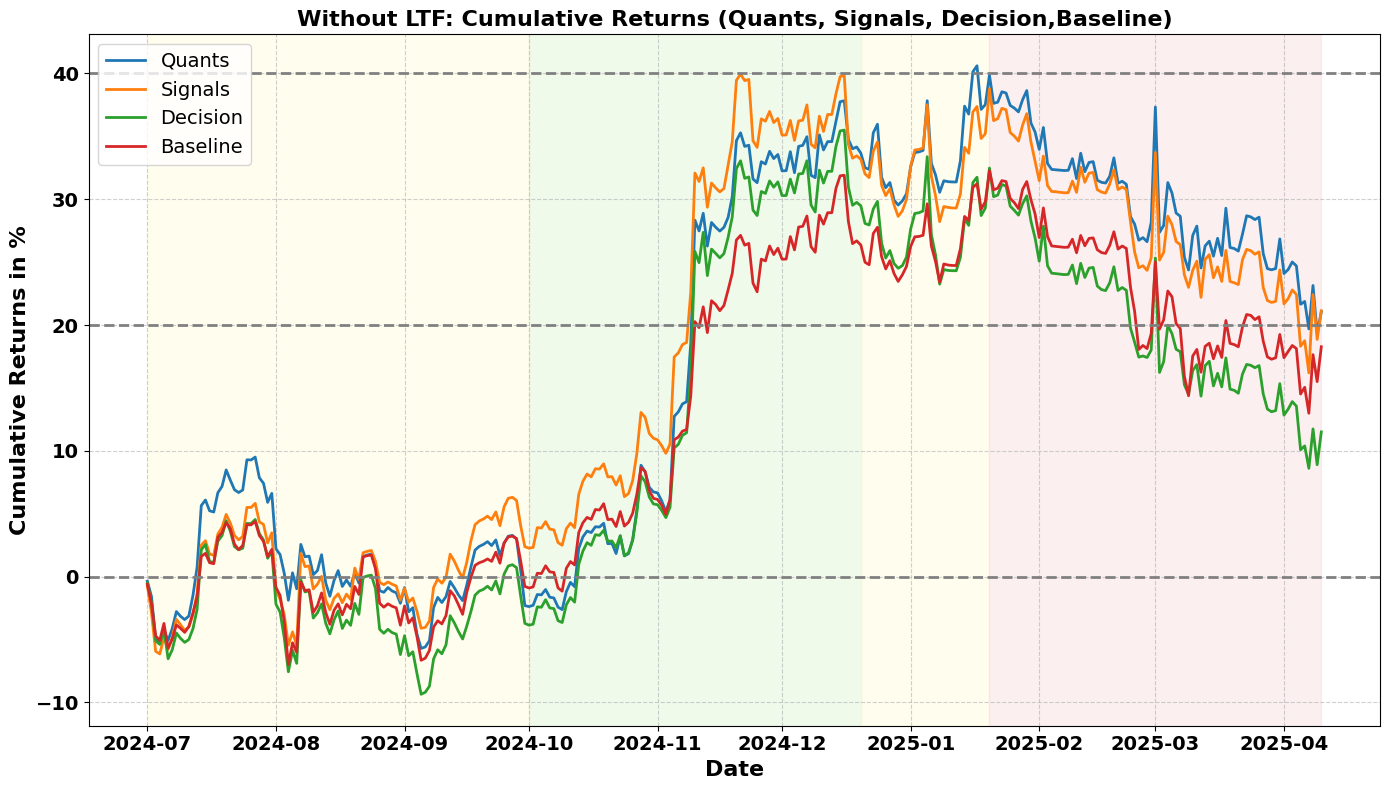

In [7]:
# Path to your state folder (update this path)
state_folder =  "without_ltf_all"

#os.path.join("..","state")

# Initialize an empty dictionary to store portfolio values
portfolio_data = {"date": [], "quants": [], "signals": [], "decision": []}

# Traverse the state folder
for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            
            for date, values in performance_log.items():
                portfolio_values = values.get("cumulative_return", {})
                portfolio_data["date"].append(date)
                portfolio_data["quants"].append(portfolio_values.get("quants", None))
                portfolio_data["signals"].append(portfolio_values.get("signals", None))
                portfolio_data["decision"].append(portfolio_values.get("decision", None))

# Convert to DataFrame for easier plotting
df = pd.DataFrame(portfolio_data)
df["date"] = pd.to_datetime(df["date"])
df.sort_values("date", inplace=True)

# Plotting with a stylish look
plt.figure(figsize=(14, 8))
plt.plot(df["date"], df["quants"], label="Quants", linestyle='-', linewidth=2)
plt.plot(df["date"], df["signals"], label="Signals", linestyle='-', linewidth=2)
plt.plot(df["date"], df["decision"], label="Decision", linestyle='-', linewidth=2)
plt.plot(df["date"],baseline_data["portfolio_overall_return"].loc[0:283], label="Baseline", linestyle='-', linewidth=2 )
# Define regimes with color codes
regimes = [
    ("Sideways", "2024-07-01", "2024-10-01", "#fffac8"),  # yellow
    ("Bullish",  "2024-10-01", "2024-12-20", "#d0f0c0"),  # green
    ("Sideways", "2024-12-20", "2025-01-20", "#fffac8"),  # yellow
    ("Bearish",  "2025-01-20", "2025-04-10", "#f4cccc"),  # red
]

# Shade background regimes
for _, start, end, color in regimes:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.3)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=2)
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2)
plt.axhline(y=40, color='gray', linestyle='--', linewidth=2)

# Aesthetic Customization
plt.title("Without LTF: Cumulative Returns (Quants, Signals, Decision,Baseline)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=16,fontweight='bold')
plt.ylabel("Cumulative Returns in %", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=14, loc="upper left")
plt.tight_layout()
plt.savefig("all_periods_cumulative_return_without_ltf",dpi=300)
plt.show()

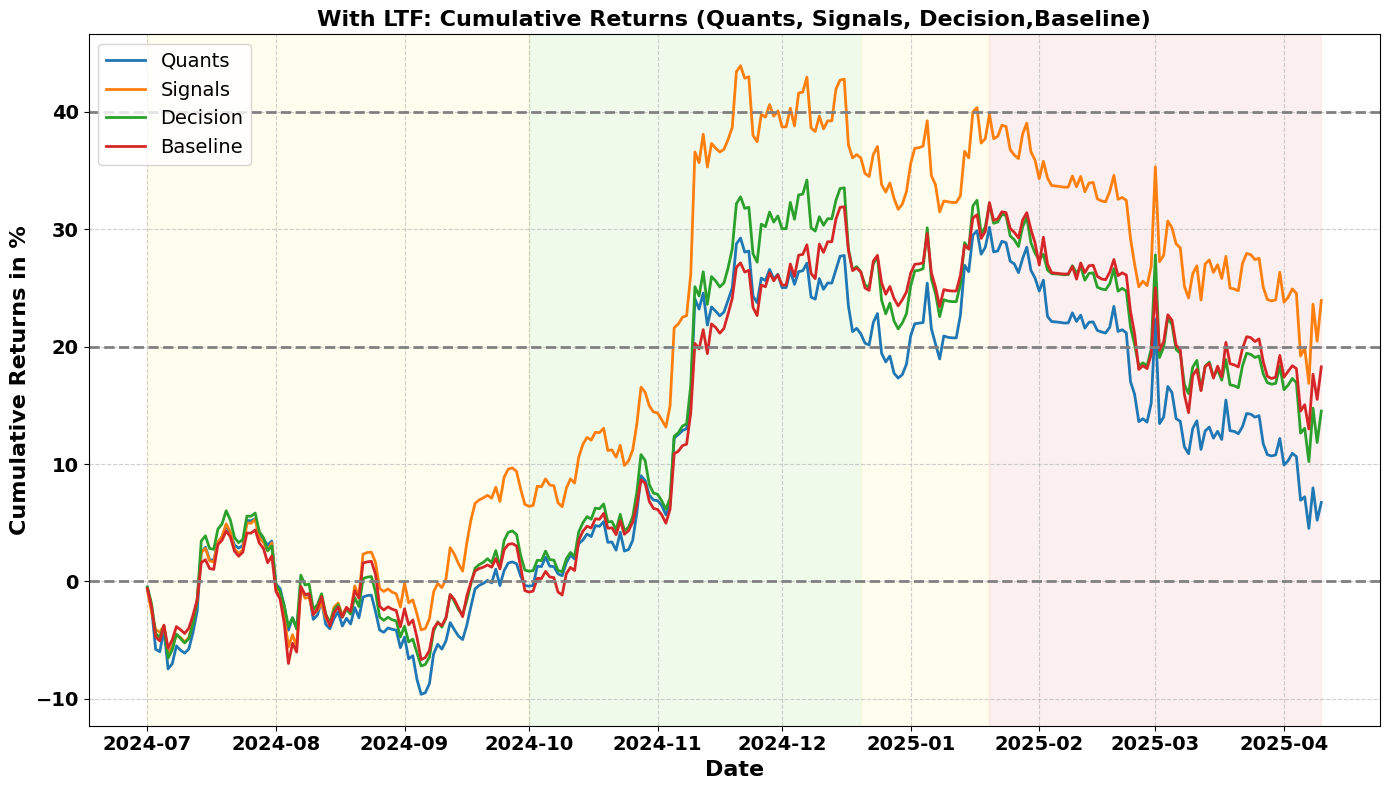

In [8]:
# Path to your state folder (update this path)
state_folder =  os.path.join("..","state")

#os.path.join("..","state")

# Initialize an empty dictionary to store portfolio values
portfolio_data = {"date": [], "quants": [], "signals": [], "decision": []}

# Traverse the state folder
for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            
            for date, values in performance_log.items():
                portfolio_values = values.get("cumulative_return", {})
                portfolio_data["date"].append(date)
                portfolio_data["quants"].append(portfolio_values.get("quants", None))
                portfolio_data["signals"].append(portfolio_values.get("signals", None))
                portfolio_data["decision"].append(portfolio_values.get("decision", None))

# Convert to DataFrame for easier plotting
df = pd.DataFrame(portfolio_data)
df["date"] = pd.to_datetime(df["date"])
df.sort_values("date", inplace=True)

# Plotting with a stylish look
plt.figure(figsize=(14, 8))
plt.plot(df["date"], df["quants"], label="Quants", linestyle='-', linewidth=2)
plt.plot(df["date"], df["signals"], label="Signals", linestyle='-', linewidth=2)
plt.plot(df["date"], df["decision"], label="Decision", linestyle='-', linewidth=2)
plt.plot(df["date"],baseline_data["portfolio_overall_return"].loc[0:283], label="Baseline", linestyle='-', linewidth=2 )
# Define regimes with color codes
regimes = [
    ("Sideways", "2024-07-01", "2024-10-01", "#fffac8"),  # yellow
    ("Bullish",  "2024-10-01", "2024-12-20", "#d0f0c0"),  # green
    ("Sideways", "2024-12-20", "2025-01-20", "#fffac8"),  # yellow
    ("Bearish",  "2025-01-20", "2025-04-10", "#f4cccc"),  # red
]

# Shade background regimes
for _, start, end, color in regimes:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.3)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=2)
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2)
plt.axhline(y=40, color='gray', linestyle='--', linewidth=2)

# Aesthetic Customization
plt.title("With LTF: Cumulative Returns (Quants, Signals, Decision,Baseline)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=16,fontweight='bold')
plt.ylabel("Cumulative Returns in %", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=14, loc="upper left")
plt.tight_layout()
plt.savefig("all_periods_cumulative_return_with_ltf",dpi=300)
plt.show()

Total Returns split by market regime (end - start) 

With LTF

In [17]:
import os
import json
import pandas as pd

# Load cumulative returns from state folder
state_folder = os.path.join("..", "state")
portfolio_data = {"date": [], "quants": [], "signals": [], "decision": []}

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                portfolio_values = values.get("cumulative_return", {})
                portfolio_data["date"].append(pd.to_datetime(date))
                portfolio_data["quants"].append(portfolio_values.get("quants", None))
                portfolio_data["signals"].append(portfolio_values.get("signals", None))
                portfolio_data["decision"].append(portfolio_values.get("decision", None))

df = pd.DataFrame(portfolio_data)
df.sort_values("date", inplace=True)

# Load baseline overall cumulative return
baseline_path = os.path.join("..", "final_datasets", "baseline_performance_full.csv")
baseline_df = pd.read_csv(baseline_path, parse_dates=["date"])
baseline_df = baseline_df[["date", "portfolio_overall_return"]].rename(columns={"portfolio_overall_return": "baseline"})

# Merge baseline
df = df.merge(baseline_df, on="date", how="left")

# Define regimes
regimes = [
    ("Sideways", "2024-07-01", "2024-10-01"),
    ("Bullish",  "2024-10-01", "2024-12-20"),
    ("Sideways", "2024-12-20", "2025-01-20"),
    ("Bearish",  "2025-01-20", "2025-04-10"),
]

# Compute total returns per regime
total_returns = {
    "Regime": [],
    "Quants Total Return (%)": [],
    "Signals Total Return (%)": [],
    "Decision Total Return (%)": [],
    "Baseline Total Return (%)": []
}

for regime_name, start_str, end_str in regimes:
    start = pd.to_datetime(start_str)
    end = pd.to_datetime(end_str)

    start_row = df[df["date"] == start]
    end_row = df[df["date"] == end]

    if start_row.empty or end_row.empty:
        continue  # skip if date not found

    # Subtract start from end
    total_returns["Regime"].append(regime_name)
    for agent in ["quants", "signals", "decision", "baseline"]:
        start_val = float(start_row[agent].values[0])
        end_val = float(end_row[agent].values[0])
        total_returns[f"{agent.capitalize()} Total Return (%)"].append(round(end_val - start_val, 2))

# Create and display table
total_returns_df = pd.DataFrame(total_returns)


In [18]:
total_returns_df

,Regime,Quants Total Return (%),Signals Total Return (%),Decision Total Return (%),Baseline Total Return (%)
0,Sideways,0.08,7.13,1.35,-0.30
1,Bullish,21.48,29.67,25.48,27.27
2,Sideways,9.08,3.73,5.83,5.91
3,Bearish,-23.43,-15.87,-17.66,-14.00


Without ltf

In [19]:
import os
import json
import pandas as pd

# Load cumulative returns from state folder
state_folder = "without_ltf_all"
portfolio_data = {"date": [], "quants": [], "signals": [], "decision": []}

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                portfolio_values = values.get("cumulative_return", {})
                portfolio_data["date"].append(pd.to_datetime(date))
                portfolio_data["quants"].append(portfolio_values.get("quants", None))
                portfolio_data["signals"].append(portfolio_values.get("signals", None))
                portfolio_data["decision"].append(portfolio_values.get("decision", None))

df = pd.DataFrame(portfolio_data)
df.sort_values("date", inplace=True)

# Load baseline overall cumulative return
baseline_path = os.path.join("..", "final_datasets", "baseline_performance_full.csv")
baseline_df = pd.read_csv(baseline_path, parse_dates=["date"])
baseline_df = baseline_df[["date", "portfolio_overall_return"]].rename(columns={"portfolio_overall_return": "baseline"})

# Merge baseline
df = df.merge(baseline_df, on="date", how="left")

# Define regimes
regimes = [
    ("Sideways", "2024-07-01", "2024-10-01"),
    ("Bullish",  "2024-10-01", "2024-12-20"),
    ("Sideways", "2024-12-20", "2025-01-20"),
    ("Bearish",  "2025-01-20", "2025-04-10"),
]

# Compute total returns per regime
total_returns = {
    "Regime": [],
    "Quants Total Return (%)": [],
    "Signals Total Return (%)": [],
    "Decision Total Return (%)": [],
    "Baseline Total Return (%)": []
}

for regime_name, start_str, end_str in regimes:
    start = pd.to_datetime(start_str)
    end = pd.to_datetime(end_str)

    start_row = df[df["date"] == start]
    end_row = df[df["date"] == end]

    if start_row.empty or end_row.empty:
        continue  # skip if date not found

    # Subtract start from end
    total_returns["Regime"].append(regime_name)
    for agent in ["quants", "signals", "decision", "baseline"]:
        start_val = float(start_row[agent].values[0])
        end_val = float(end_row[agent].values[0])
        total_returns[f"{agent.capitalize()} Total Return (%)"].append(round(end_val - start_val, 2))

# Create and display table
total_returns_df = pd.DataFrame(total_returns)


In [20]:
total_returns_df

,Regime,Quants Total Return (%),Signals Total Return (%),Decision Total Return (%),Baseline Total Return (%)
0,Sideways,-2.02,2.99,-3.38,-0.30
1,Bullish,36.05,30.92,33.34,27.27
2,Sideways,6.21,5.63,3.01,5.91
3,Bearish,-18.82,-17.66,-20.98,-14.00


All metrics:  Cumulative Returns Sharpe ratio Daily returns(avg) Weekly Returns(avg)  accuracy (avg)

Daily Returns

In [8]:
import os
import json
import pandas as pd
import numpy as np

# Set your state folder
state_folder = "without_ltf_all"

# Initialize list to collect daily return data
records = []

# Traverse the folder and extract agent data
for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                daily_returns = values.get("daily_returns", {})
                record = {
                    "date": pd.to_datetime(date),
                    "quants": daily_returns.get("quants", None),
                    "signals": daily_returns.get("signals", None),
                    "decision": daily_returns.get("decision", None)
                }
                records.append(record)

# Create DataFrame from records
df = pd.DataFrame(records)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Load and merge baseline data
baseline_data = pd.read_csv(os.path.join('..', 'final_datasets', 'baseline_performance_full.csv'))
baseline_data["date"] = pd.to_datetime(baseline_data["date"])
df = df.merge(baseline_data[["date", "portfolio_daily_return"]], on="date", how="left")
df.rename(columns={"portfolio_daily_return": "baseline"}, inplace=True)

# Define regimes (Sideways is merged)
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# Output dictionary
output = {
    "Regime": [],
    "Quants Return": [],
    "Signals Return": [],
    "Decision Return": [],
    "Baseline Return": []
}

# Helper to format mean ± std
def fmt(col, df_subset):
    vals = df_subset[col].dropna()
    if len(vals) == 0:
        return "NA"
    return f"{np.round(vals.mean(), 3)} ± {np.round(vals.std(), 4)}"

# Add "All Periods"
output["Regime"].append("All Periods")
output["Quants Return"].append(fmt("quants", df))
output["Signals Return"].append(fmt("signals", df))
output["Decision Return"].append(fmt("decision", df))
output["Baseline Return"].append(fmt("baseline", df))

# Regime-wise calculations
for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        regime_df = df[(df["date"] >= start_date) & (df["date"] < end_date)]
        regime_df_list.append(regime_df)

    merged_df = pd.concat(regime_df_list)

    output["Regime"].append(regime)
    output["Quants Return"].append(fmt("quants", merged_df))
    output["Signals Return"].append(fmt("signals", merged_df))
    output["Decision Return"].append(fmt("decision", merged_df))
    output["Baseline Return"].append(fmt("baseline", merged_df))

# Final output DataFrame
regime_df = pd.DataFrame(output)



In [9]:
regime_df

,Regime,Quants Return,Signals Return,Decision Return,Baseline Return
0,All Periods,0.08 ± 1.5826,0.08 ± 1.6097,0.052 ± 1.6309,0.069 ± 1.3799
1,Sideways,-0.002 ± 1.417,0.005 ± 1.5213,-0.053 ± 1.6024,-0.011 ± 1.3665
2,Bullish,0.458 ± 1.6555,0.415 ± 1.6102,0.456 ± 1.5872,0.378 ± 1.2708
3,Bearish,-0.151 ± 1.7011,-0.128 ± 1.7005,-0.18 ± 1.6525,-0.116 ± 1.4446


With LTF

In [4]:
import os
import json
import pandas as pd
import numpy as np

# Set your state folder
state_folder = os.path.join("..","state")

# Initialize list to collect daily return data
records = []

# Traverse the folder and extract data
for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                daily_returns = values.get("daily_returns", {})
                record = {
                    "date": pd.to_datetime(date),
                    "quants": daily_returns.get("quants", None),
                    "signals": daily_returns.get("signals", None),
                    "decision": daily_returns.get("decision", None)
                }
                records.append(record)

# Create DataFrame
df = pd.DataFrame(records)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Define regimes (Sideways is merged)
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# Initialize output
output = {
    "Regime": [],
    "Quants Return": [],
    "Signals Return": [],
    "Decision Return": []
}

# Helper to format mean ± std
def fmt(col, df_subset):
    vals = df_subset[col].dropna()
    if len(vals) == 0:
        return "NA"
    return f"{np.round(vals.mean(), 3)} ± {np.round(vals.std(), 4)}"

# Add "All Periods"
output["Regime"].append("All Periods")
output["Quants Return"].append(fmt("quants", df))
output["Signals Return"].append(fmt("signals", df))
output["Decision Return"].append(fmt("decision", df))

# Regime-wise calculations
for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        regime_df = df[(df["date"] >= start_date) & (df["date"] < end_date)]
        regime_df_list.append(regime_df)

    merged_df = pd.concat(regime_df_list)

    output["Regime"].append(regime)
    output["Quants Return"].append(fmt("quants", merged_df))
    output["Signals Return"].append(fmt("signals", merged_df))
    output["Decision Return"].append(fmt("decision", merged_df))

# Final DataFrame
regime_df = pd.DataFrame(output)


In [5]:
regime_df

,Regime,Quants Return,Signals Return,Decision Return
0,All Periods,0.035 ± 1.5194,0.088 ± 1.5929,0.059 ± 1.5248
1,Sideways,0.01 ± 1.4399,0.031 ± 1.4367,-0.005 ± 1.4293
2,Bullish,0.33 ± 1.4638,0.396 ± 1.6376,0.374 ± 1.5219
3,Bearish,-0.207 ± 1.6486,-0.134 ± 1.7195,-0.154 ± 1.6185


Sharpe

In [10]:
import os
import json
import pandas as pd
import numpy as np

# Set your state folder
state_folder = "without_ltf_all"

# Collect daily returns
records = []

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                daily_returns = values.get("daily_returns", {})
                records.append({
                    "date": pd.to_datetime(date),
                    "quants": daily_returns.get("quants", None),
                    "signals": daily_returns.get("signals", None),
                    "decision": daily_returns.get("decision", None)
                })

# Convert to DataFrame
df = pd.DataFrame(records)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Load baseline return data
baseline_data = pd.read_csv(os.path.join('..', 'final_datasets', 'baseline_performance_full.csv'))
baseline_data["date"] = pd.to_datetime(baseline_data["date"])
df = df.merge(baseline_data[["date", "portfolio_daily_return"]], on="date", how="left")
df.rename(columns={"portfolio_daily_return": "baseline"}, inplace=True)

# Define regimes
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# Compute Sharpe ratio per agent per regime
output = []

def compute_sharpe(col, df_section):
    vals = df_section[col].dropna()
    std = vals.std()
    return round(vals.mean() / std, 4) if std != 0 else "NA"

# Add "All Periods"
output.append({
    "Regime": "All Periods",
    "Quants Sharpe": compute_sharpe("quants", df),
    "Signals Sharpe": compute_sharpe("signals", df),
    "Decision Sharpe": compute_sharpe("decision", df),
    "Baseline Sharpe": compute_sharpe("baseline", df)
})

# Add regime-wise entries
for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        regime_df = df[(df["date"] >= start_date) & (df["date"] < end_date)]
        regime_df_list.append(regime_df)
    combined = pd.concat(regime_df_list)

    output.append({
        "Regime": regime,
        "Quants Sharpe": compute_sharpe("quants", combined),
        "Signals Sharpe": compute_sharpe("signals", combined),
        "Decision Sharpe": compute_sharpe("decision", combined),
        "Baseline Sharpe": compute_sharpe("baseline", combined)
    })

# Final DataFrame
sharpe_by_regime_df = pd.DataFrame(output)


In [11]:
sharpe_by_regime_df

,Regime,Quants Sharpe,Signals Sharpe,Decision Sharpe,Baseline Sharpe
0,All Periods,0.0504,0.0499,0.0318,0.0497
1,Sideways,-0.0014,0.0033,-0.0333,-0.0081
2,Bullish,0.2765,0.2578,0.2873,0.2972
3,Bearish,-0.0889,-0.0750,-0.1088,-0.0805


With LTF

In [2]:
import os
import json
import pandas as pd
import numpy as np

# Set your state folder
state_folder = os.path.join("..","state")

# Collect daily returns
records = []

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(os.path.join(state_folder, filename), "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                daily_returns = values.get("daily_returns", {})
                records.append({
                    "date": pd.to_datetime(date),
                    "quants": daily_returns.get("quants", None),
                    "signals": daily_returns.get("signals", None),
                    "decision": daily_returns.get("decision", None)
                })

df = pd.DataFrame(records)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Define regimes
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# Compute Sharpe ratio per agent per regime
output = []

def compute_sharpe(col, df_section):
    vals = df_section[col].dropna()
    std = vals.std()
    return round(vals.mean() / std, 4) if std != 0 else "NA"

# First add 'All Periods'
output.append({
    "Regime": "All Periods",
    "Quants Sharpe": compute_sharpe("quants", df),
    "Signals Sharpe": compute_sharpe("signals", df),
    "Decision Sharpe": compute_sharpe("decision", df)
})

# Then each regime
for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        regime_df = df[(df["date"] >= start_date) & (df["date"] < end_date)]
        regime_df_list.append(regime_df)
    combined = pd.concat(regime_df_list)

    output.append({
        "Regime": regime,
        "Quants Sharpe": compute_sharpe("quants", combined),
        "Signals Sharpe": compute_sharpe("signals", combined),
        "Decision Sharpe": compute_sharpe("decision", combined)
    })

# Final DataFrame
sharpe_by_regime_df = pd.DataFrame(output)


In [3]:
sharpe_by_regime_df

,Regime,Quants Sharpe,Signals Sharpe,Decision Sharpe
0,All Periods,0.0227,0.0553,0.0388
1,Sideways,0.0068,0.0216,-0.0033
2,Bullish,0.2252,0.2417,0.2457
3,Bearish,-0.1254,-0.0778,-0.0949


Accuracy

In [48]:
import os
import json
import pandas as pd
import numpy as np

# Path to state folder
state_folder = "without_ltf_all"

# Step 1: Load all accuracy data with date
records = []

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                acc = values.get("accuracy", {})
                records.append({
                    "date": pd.to_datetime(date),
                    "quants": acc.get("quants", None),
                    "signals": acc.get("signals", None),
                    "decision": acc.get("decision", None)
                })

df = pd.DataFrame(records)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Step 2: Average accuracy across all periods
overall_accuracy = {
    "Regime": "All Periods",
    "Quants Accuracy": round(df["quants"].dropna().mean(), 4),
    "Signals Accuracy": round(df["signals"].dropna().mean(), 4),
    "Decision Accuracy": round(df["decision"].dropna().mean(), 4)
}

# Step 3: Regime definitions (Sideways = 2 periods merged)
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# Step 4: Compute mean accuracy for each regime
rows = []

for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        part = df[(df["date"] >= start_date) & (df["date"] < end_date)]
        regime_df_list.append(part)
    combined = pd.concat(regime_df_list)

    rows.append({
        "Regime": regime,
        "Quants Accuracy": round(combined["quants"].dropna().mean(), 4),
        "Signals Accuracy": round(combined["signals"].dropna().mean(), 4),
        "Decision Accuracy": round(combined["decision"].dropna().mean(), 4)
    })

# Append full-period accuracy at top
rows.insert(0, overall_accuracy)

# Convert to DataFrame
accuracy_df = pd.DataFrame(rows)


In [49]:
accuracy_df


,Regime,Quants Accuracy,Signals Accuracy,Decision Accuracy
0,All Periods,0.6297,0.6358,0.6357
1,Sideways,0.6533,0.6377,0.6472
2,Bullish,0.6249,0.6427,0.6313
3,Bearish,0.6033,0.6298,0.6266


With ltf

In [15]:
import os
import json
import pandas as pd
import numpy as np

# Path to state folder
state_folder = os.path.join("..","state")

# Step 1: Load all accuracy data with date
records = []

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                acc = values.get("accuracy", {})
                records.append({
                    "date": pd.to_datetime(date),
                    "quants": acc.get("quants", None),
                    "signals": acc.get("signals", None),
                    "decision": acc.get("decision", None)
                })

df = pd.DataFrame(records)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Step 2: Average accuracy across all periods
overall_accuracy = {
    "Regime": "All Periods",
    "Quants Accuracy": round(df["quants"].dropna().mean(), 4),
    "Signals Accuracy": round(df["signals"].dropna().mean(), 4),
    "Decision Accuracy": round(df["decision"].dropna().mean(), 4)
}

# Step 3: Regime definitions (Sideways = 2 periods merged)
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# Step 4: Compute mean accuracy for each regime
rows = []

for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        part = df[(df["date"] >= start_date) & (df["date"] < end_date)]
        regime_df_list.append(part)
    combined = pd.concat(regime_df_list)

    rows.append({
        "Regime": regime,
        "Quants Accuracy": round(combined["quants"].dropna().mean(), 4),
        "Signals Accuracy": round(combined["signals"].dropna().mean(), 4),
        "Decision Accuracy": round(combined["decision"].dropna().mean(), 4)
    })

# Append full-period accuracy at top
rows.insert(0, overall_accuracy)

# Convert to DataFrame
accuracy_df = pd.DataFrame(rows)


In [16]:
accuracy_df

,Regime,Quants Accuracy,Signals Accuracy,Decision Accuracy
0,All Periods,0.6165,0.6467,0.6402
1,Sideways,0.6561,0.6910,0.6809
2,Bullish,0.5921,0.6039,0.6177
3,Bearish,0.5852,0.6163,0.6020


All periods returns with ltf

Weekly returns plot

In [11]:
import os
import json
import pandas as pd
import numpy as np

# --- Load weekly return data from state folder ---
state_folder = "without_ltf_all"
records = []

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                returns = values.get("returns", {})
                record = {
                    "date": pd.to_datetime(date),
                    "quants": returns.get("quants", {}).get("weekly", None),
                    "signals": returns.get("signals", {}).get("weekly", None),
                    "decision": returns.get("decision", {}).get("weekly", None)
                }
                records.append(record)

df = pd.DataFrame(records)
df.dropna(subset=["quants", "signals", "decision"], how="all", inplace=True)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# --- Load baseline weekly returns ---
baseline_path = os.path.join("..", "final_datasets", "baseline_performance_full.csv")
baseline_df = pd.read_csv(baseline_path, parse_dates=["date"])
baseline_df = baseline_df[["date", "return_7d_avg"]].rename(columns={"return_7d_avg": "baseline"})

# Merge on date
df = df.merge(baseline_df, on="date", how="left")

# --- Define regimes ---
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# --- Prepare output table ---
output = {
    "Regime": [],
    "Quants Weekly Return (%)": [],
    "Signals Weekly Return (%)": [],
    "Decision Weekly Return (%)": [],
    "Baseline Weekly Return (%)": []
}

# Helper to compute mean % return
def avg(col, df_subset):
    vals = df_subset[col].dropna()
    return round(vals.mean(), 3) if not vals.empty else "NA"

# All Periods
output["Regime"].append("All Periods")
output["Quants Weekly Return (%)"].append(avg("quants", df))
output["Signals Weekly Return (%)"].append(avg("signals", df))
output["Decision Weekly Return (%)"].append(avg("decision", df))
output["Baseline Weekly Return (%)"].append(avg("baseline", df))

# Per-regime
for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        regime_df_list.append(df[(df["date"] >= start_date) & (df["date"] < end_date)])
    merged_df = pd.concat(regime_df_list)

    output["Regime"].append(regime)
    output["Quants Weekly Return (%)"].append(avg("quants", merged_df))
    output["Signals Weekly Return (%)"].append(avg("signals", merged_df))
    output["Decision Weekly Return (%)"].append(avg("decision", merged_df))
    output["Baseline Weekly Return (%)"].append(avg("baseline", merged_df))

# --- Final output ---
weekly_returns_df = pd.DataFrame(output)


In [12]:
weekly_returns_df

,Regime,Quants Weekly Return (%),Signals Weekly Return (%),Decision Weekly Return (%),Baseline Weekly Return (%)
0,All Periods,0.051,0.074,0.049,0.059
1,Sideways,-0.061,0.012,-0.033,0.009
2,Bullish,0.404,0.380,0.406,0.324
3,Bearish,-0.075,-0.088,-0.127,-0.087


With ltf

In [13]:
import os
import json
import pandas as pd
import numpy as np

# --- Load weekly return data from state folder ---
state_folder = os.path.join("..","state")
records = []

for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})
            for date, values in performance_log.items():
                returns = values.get("returns", {})
                record = {
                    "date": pd.to_datetime(date),
                    "quants": returns.get("quants", {}).get("weekly", None),
                    "signals": returns.get("signals", {}).get("weekly", None),
                    "decision": returns.get("decision", {}).get("weekly", None)
                }
                records.append(record)

df = pd.DataFrame(records)
df.dropna(subset=["quants", "signals", "decision"], how="all", inplace=True)
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# --- Load baseline weekly returns ---
baseline_path = os.path.join("..", "final_datasets", "baseline_performance_full.csv")
baseline_df = pd.read_csv(baseline_path, parse_dates=["date"])
baseline_df = baseline_df[["date", "return_7d_avg"]].rename(columns={"return_7d_avg": "baseline"})

# Merge on date
df = df.merge(baseline_df, on="date", how="left")

# --- Define regimes ---
regimes = {
    "Sideways": [("2024-07-01", "2024-10-01"), ("2024-12-15", "2025-01-15")],
    "Bullish": [("2024-10-01", "2024-12-15")],
    "Bearish": [("2025-01-15", "2025-04-10")]
}

# --- Prepare output table ---
output = {
    "Regime": [],
    "Quants Weekly Return (%)": [],
    "Signals Weekly Return (%)": [],
    "Decision Weekly Return (%)": [],
    "Baseline Weekly Return (%)": []
}

# Helper to compute mean % return
def avg(col, df_subset):
    vals = df_subset[col].dropna()
    return round(vals.mean(), 3) if not vals.empty else "NA"

# All Periods
output["Regime"].append("All Periods")
output["Quants Weekly Return (%)"].append(avg("quants", df))
output["Signals Weekly Return (%)"].append(avg("signals", df))
output["Decision Weekly Return (%)"].append(avg("decision", df))
output["Baseline Weekly Return (%)"].append(avg("baseline", df))

# Per-regime
for regime, periods in regimes.items():
    regime_df_list = []
    for start, end in periods:
        start_date = pd.to_datetime(start)
        end_date = pd.to_datetime(end)
        regime_df_list.append(df[(df["date"] >= start_date) & (df["date"] < end_date)])
    merged_df = pd.concat(regime_df_list)

    output["Regime"].append(regime)
    output["Quants Weekly Return (%)"].append(avg("quants", merged_df))
    output["Signals Weekly Return (%)"].append(avg("signals", merged_df))
    output["Decision Weekly Return (%)"].append(avg("decision", merged_df))
    output["Baseline Weekly Return (%)"].append(avg("baseline", merged_df))

# --- Final output ---
weekly_returns_df = pd.DataFrame(output)


In [14]:
weekly_returns_df

,Regime,Quants Weekly Return (%),Signals Weekly Return (%),Decision Weekly Return (%),Baseline Weekly Return (%)
0,All Periods,0.036,0.076,0.055,0.059
1,Sideways,-0.009,0.033,-0.013,0.009
2,Bullish,0.315,0.373,0.358,0.324
3,Bearish,-0.128,-0.105,-0.096,-0.087


Weekly returns tracking

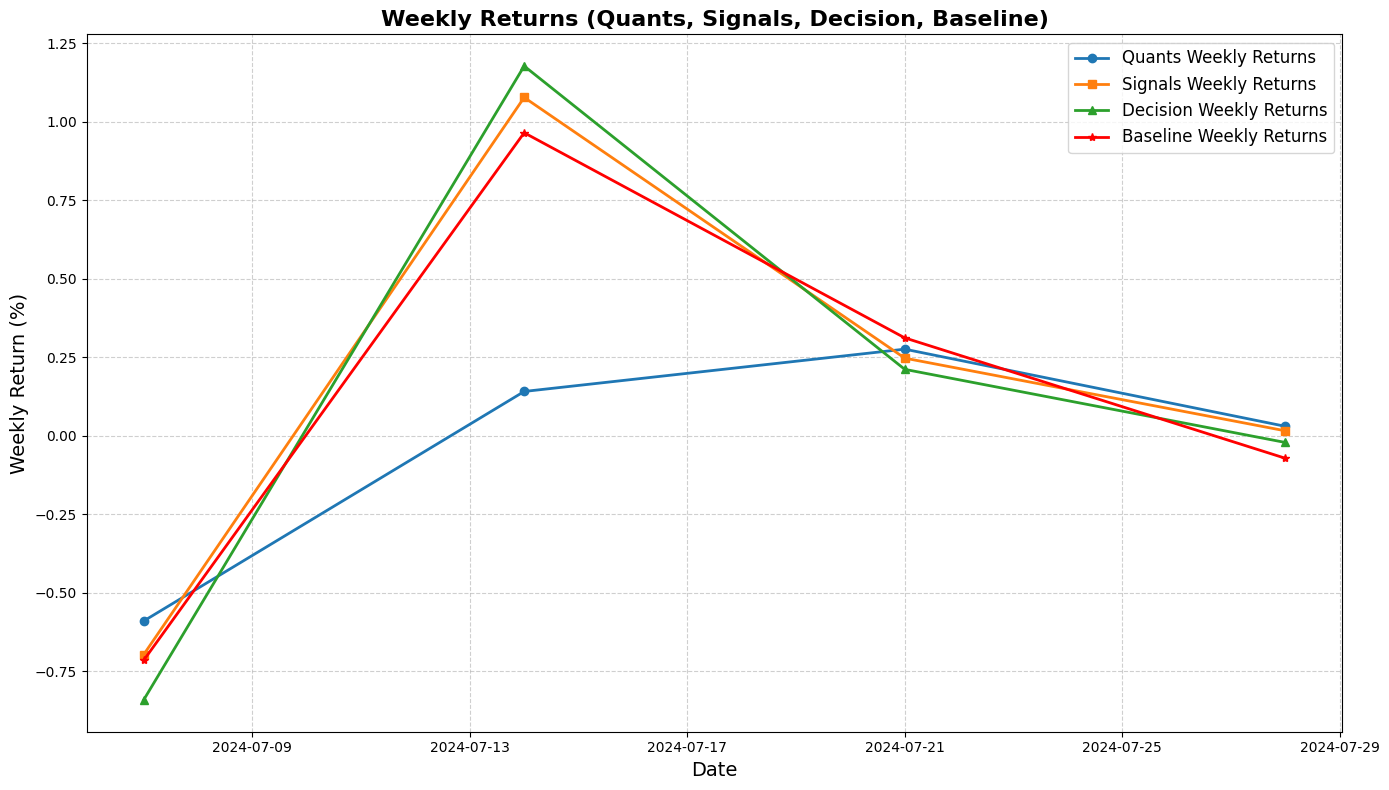

In [33]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Initialize an empty list to store weekly returns (ensuring consistent lengths)
weekly_returns = []

# Define the target dates for weekly returns
dates = ["2024-07-07", "2024-07-14", "2024-07-21", "2024-07-28"]
target_dates = set(dates)  # Using a set for faster lookup

# Traverse the state folder and load only the required date files
state_folder = os.path.join("..", "state")  # Update this path to your local directory
for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})

            # Only process the target dates
            for date in target_dates:
                values = performance_log.get(date, {})
                if values:  # Skip if the date is not in the log
                    returns = values.get("returns", {})
                    weekly_returns.append({
                        "date": date,
                        "quants": returns.get("quants", {}).get("weekly", None),
                        "signals": returns.get("signals", {}).get("weekly", None),
                        "decision": returns.get("decision", {}).get("weekly", None)
                    })

# Convert to DataFrame for easier plotting
df_weekly = pd.DataFrame(weekly_returns)
df_weekly["date"] = pd.to_datetime(df_weekly["date"])
df_weekly.sort_values("date", inplace=True)

# Load and align baseline data
baseline_data["date"] = pd.to_datetime(baseline_data["date"])
baseline_data = baseline_data[baseline_data["date"].isin(df_weekly["date"])]

# Aligning baseline values with df_weekly
df_weekly = df_weekly.merge(
    baseline_data[["date", "return_7d_avg"]], 
    on="date", 
    how="left"
)
df_weekly.rename(columns={"return_7d_avg": "baseline"}, inplace=True)

# Plotting Weekly Returns (Line Graph)
plt.figure(figsize=(14, 8))
plt.plot(df_weekly["date"], df_weekly["quants"], label="Quants Weekly Returns", linestyle='-', marker='o', linewidth=2)
plt.plot(df_weekly["date"], df_weekly["signals"], label="Signals Weekly Returns", linestyle='-', marker='s', linewidth=2)
plt.plot(df_weekly["date"], df_weekly["decision"], label="Decision Weekly Returns", linestyle='-', marker='^', linewidth=2)
plt.plot(df_weekly["date"], df_weekly["baseline"], label="Baseline Weekly Returns", linestyle='-', marker='*', linewidth=2, color='red')

# Aesthetic Customization
plt.title("Weekly Returns (Quants, Signals, Decision, Baseline)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Weekly Return (%)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc="best")
plt.tight_layout()
plt.show()


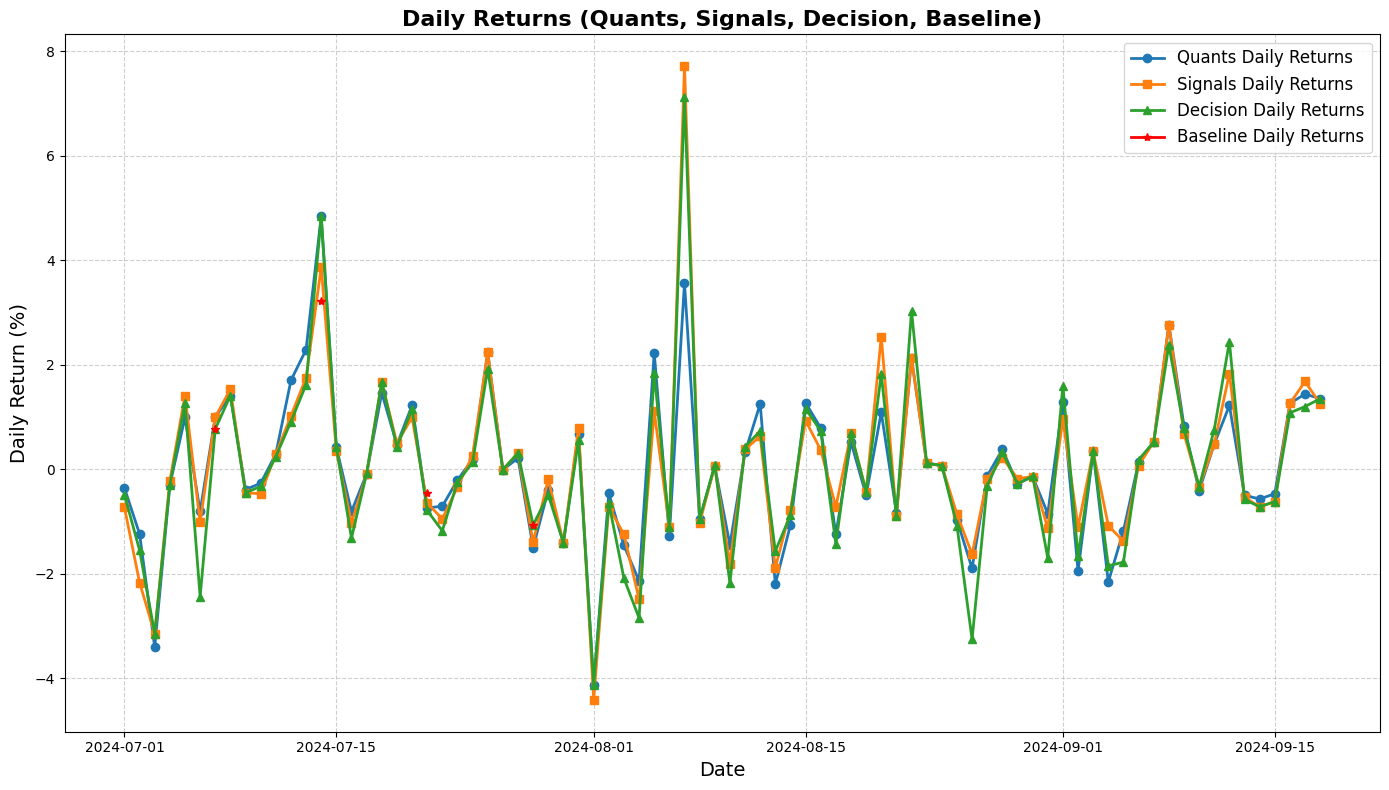

In [34]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

# Initialize an empty list to store daily returns
daily_returns = []

# Traverse the state folder and load daily returns directly
state_folder = os.path.join("..", "state")  # Update this path to your local directory
for filename in sorted(os.listdir(state_folder)):
    if filename.endswith(".json"):
        file_path = os.path.join(state_folder, filename)
        with open(file_path, "r") as file:
            data = json.load(file)
            performance_log = data.get("performance_log", {})

            # Collect daily returns for each date in the performance log
            for date, values in performance_log.items():
                daily = values.get("daily_returns", {})
                if daily:  # Skip if daily returns are not present
                    daily_returns.append({
                        "date": date,
                        "quants": daily.get("quants", None),
                        "signals": daily.get("signals", None),
                        "decision": daily.get("decision", None)
                    })

# Convert to DataFrame for easier plotting
df_daily = pd.DataFrame(daily_returns)
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_daily.sort_values("date", inplace=True)

# Aligning baseline values with df_daily using the already loaded baseline_data
df_daily = df_daily.merge(
    baseline_data[["date", "portfolio_daily_return"]], 
    on="date", 
    how="left"
)
df_daily.rename(columns={"portfolio_daily_return": "baseline"}, inplace=True)

# Plotting Daily Returns (Line Graph)
plt.figure(figsize=(14, 8))
plt.plot(df_daily["date"], df_daily["quants"], label="Quants Daily Returns", linestyle='-', marker='o', linewidth=2)
plt.plot(df_daily["date"], df_daily["signals"], label="Signals Daily Returns", linestyle='-', marker='s', linewidth=2)
plt.plot(df_daily["date"], df_daily["decision"], label="Decision Daily Returns", linestyle='-', marker='^', linewidth=2)
plt.plot(df_daily["date"], df_daily["baseline"], label="Baseline Daily Returns", linestyle='-', marker='*', linewidth=2, color='red')

# Aesthetic Customization
plt.title("Daily Returns (Quants, Signals, Decision, Baseline)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=14)
plt.ylabel("Daily Return (%)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc="best")
plt.tight_layout()
plt.show()
